In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_path = "../data/LD2011_2014.txt"

In [3]:
df = pd.read_csv(
    data_path,
    sep=";",
    decimal=",",
    usecols=[0, 1]    # Get cols 0 and 1 (Load just the first consumer)
)
df.head()

,Unnamed: 0,MT_001
0,2011-01-01 00:15:00,0.0
1,2011-01-01 00:30:00,0.0
2,2011-01-01 00:45:00,0.0
3,2011-01-01 01:00:00,0.0
4,2011-01-01 01:15:00,0.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  140256 non-null  str    
 1   MT_001      140256 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.1 MB


In [5]:
df.columns

Index(['Unnamed: 0', 'MT_001'], dtype='str')

In [6]:
df.columns = ["timestamp", "load"]
df.columns

Index(['timestamp', 'load'], dtype='str')

In [7]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()

,timestamp,load
0,2011-01-01 00:15:00,0.0
1,2011-01-01 00:30:00,0.0
2,2011-01-01 00:45:00,0.0
3,2011-01-01 01:00:00,0.0
4,2011-01-01 01:15:00,0.0


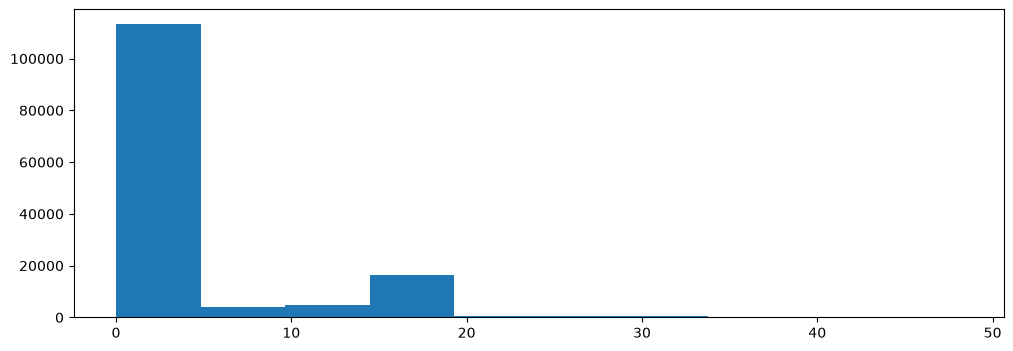

In [8]:
plt.figure(figsize=(12, 4))
plt.hist(df["load"])
plt.show()

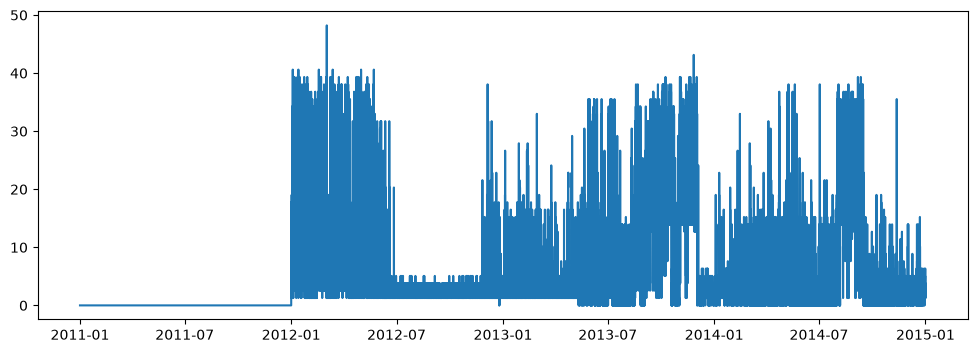

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"], df["load"])
plt.show()

# Check 0s

In [10]:
(df["load"] == 0).mean() 

np.float64(0.29049024640657084)

In [11]:
df.groupby(df["timestamp"].dt.year)["load"].apply(
    lambda x: (x == 0).mean()
)

timestamp
2011    1.000000
2012    0.000370
2013    0.052939
2014    0.109475
2015    0.000000
Name: load, dtype: float64

In [12]:
df = df.loc[df["timestamp"] >= "2012-01-01"].copy()

In [13]:
(df["load"] == 0).mean() 

np.float64(0.05421177186196147)

In [14]:
df.groupby(df["timestamp"].dt.year)["load"].apply(
    lambda x: (x == 0).mean()
)

timestamp
2012    0.000370
2013    0.052939
2014    0.109475
2015    0.000000
Name: load, dtype: float64

In [15]:
print(df.shape)
print(df["timestamp"].min())
print(df["timestamp"].max())
print(df["load"].describe())

(105217, 2)
2012-01-01 00:00:00
2015-01-01 00:00:00
count    105217.000000
mean          5.293122
std           6.382257
min           0.000000
25%           1.269036
50%           2.538071
75%           5.076142
max          48.223350
Name: load, dtype: float64


# Check NAs

In [16]:
df.isna().sum()

timestamp    0
load         0
dtype: int64

In [17]:
df.isna().mean()

timestamp    0.0
load         0.0
dtype: float64

# Check duplicated timestamp

In [18]:
df["timestamp"].duplicated().sum()

np.int64(0)

In [19]:
df["timestamp"].duplicated().mean()

np.float64(0.0)

# Check time intervals

In [20]:
df["timestamp"].diff().value_counts().head()

timestamp
0 days 00:15:00    105216
Name: count, dtype: int64

# Basic summary statistics

In [21]:
df.describe()

,timestamp,load
count,105217,105217.000000
mean,2013-07-02 00:00:00,5.293122
min,2012-01-01 00:00:00,0.000000
25%,2012-10-01 00:00:00,1.269036
50%,2013-07-02 00:00:00,2.538071
75%,2014-04-02 00:00:00,5.076142
max,2015-01-01 00:00:00,48.223350
std,NaN,6.382257


# Basic plots

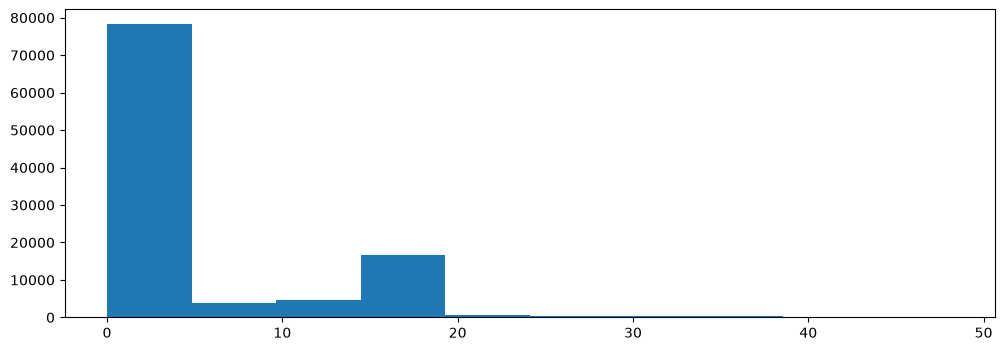

In [22]:
plt.figure(figsize=(12, 4))
plt.hist(df["load"])
plt.show()

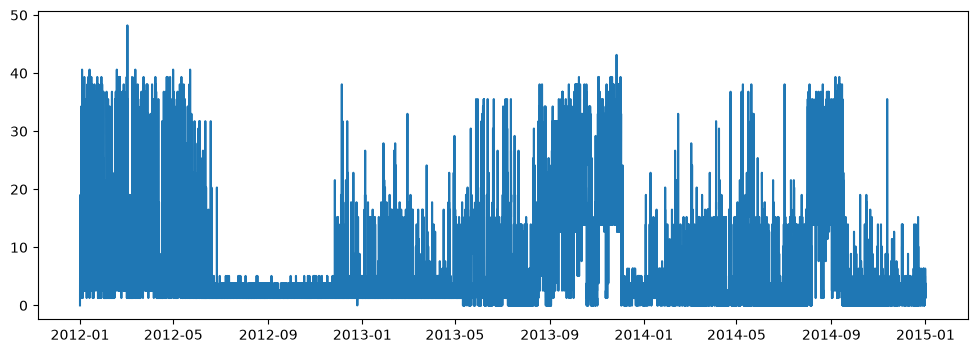

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"], df["load"])
plt.show()

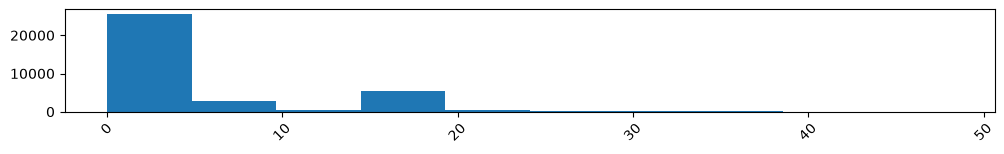

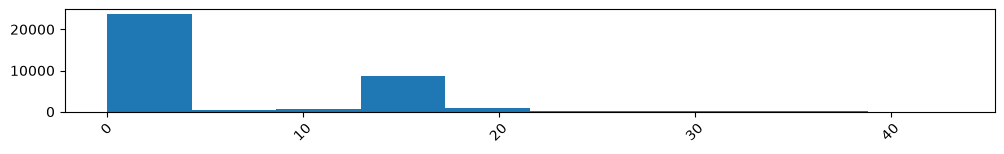

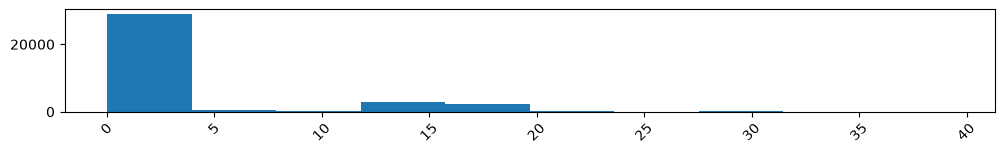

In [24]:
for year in [2012, 2013, 2014]:
    yearly = df.loc[df["timestamp"].dt.year == year]
    plt.figure(figsize=(12, 4/3))
    plt.hist(yearly["load"])
    plt.xticks(rotation=45)
    plt.show()

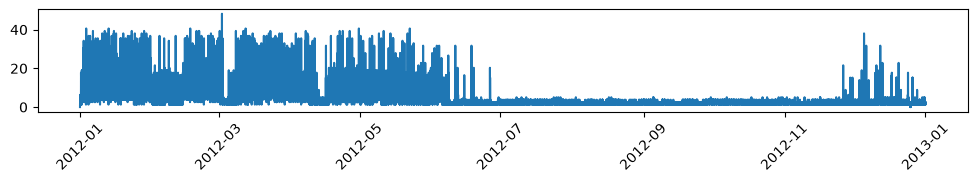

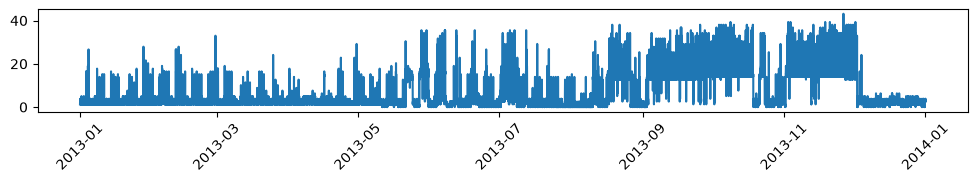

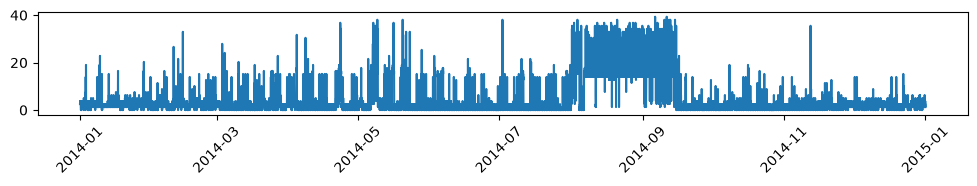

In [25]:
for year in [2012, 2013, 2014]:
    yearly = df.loc[df["timestamp"].dt.year == year]
    plt.figure(figsize=(12, 4/3))
    plt.plot(yearly["timestamp"], yearly["load"])
    plt.xticks(rotation=45)
    plt.show()

In [26]:
def plot_ts_by_year_client(client_id):
    
    # Load timestamp + requested client
    df = pd.read_csv(
        data_path,
        sep=";",
        decimal=",",
        usecols=[0, client_id]
    )
    
    # Rename columns
    df.columns = ["timestamp", "load"]
    
    # Convert timestamp
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    
    # Plot each year
    for year in [2012, 2013, 2014]:
        
        yearly = df.loc[
            df["timestamp"].dt.year == year
        ]
        
        plt.figure(figsize=(12, 4/3))
        
        plt.plot(
            yearly["timestamp"],
            yearly["load"]
        )
        
        plt.title(f"Client {client_id} — {year}")
        plt.xlabel("Date")
        plt.ylabel("Load (kW)")
        plt.xticks(rotation=45)
        plt.show()

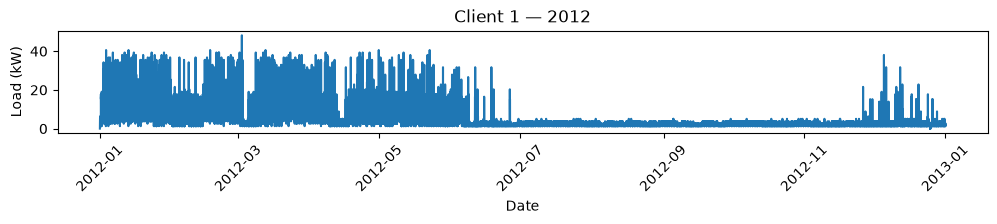

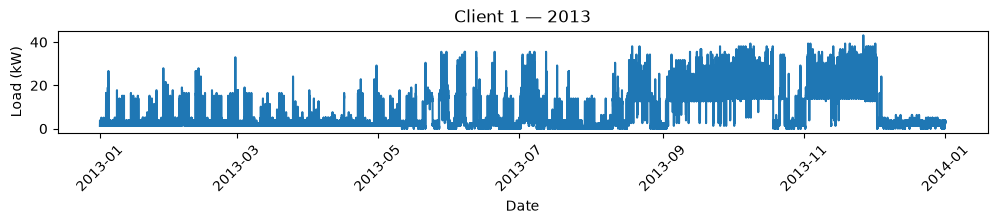

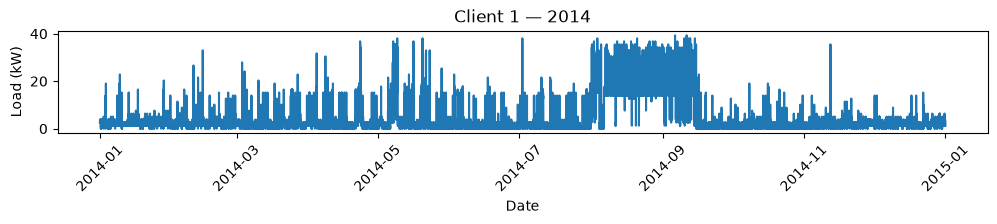

In [27]:
plot_ts_by_year_client(1)

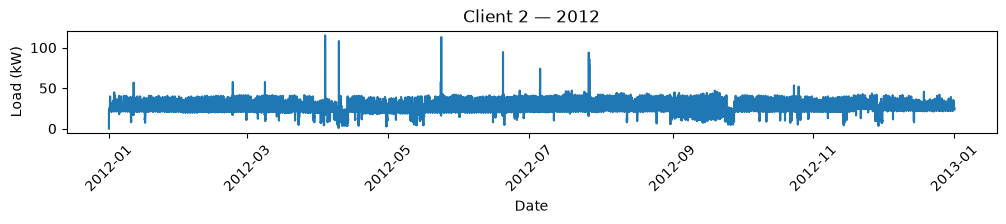

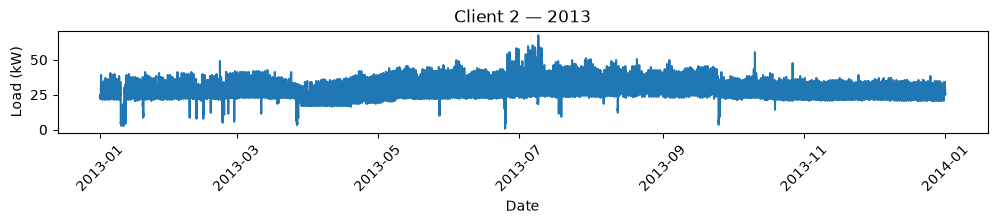

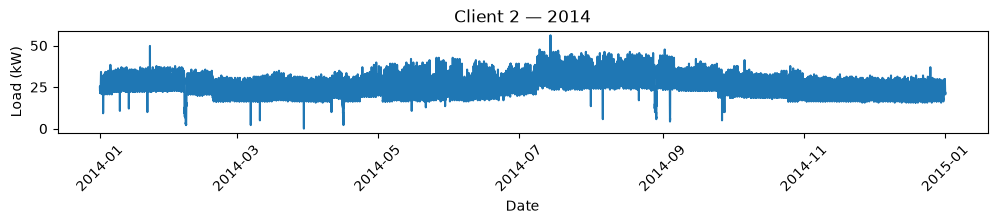

In [28]:
plot_ts_by_year_client(2)

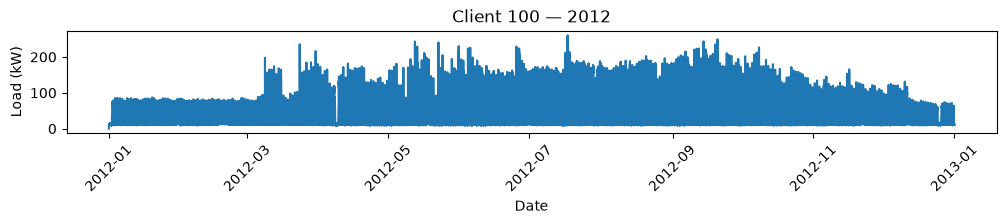

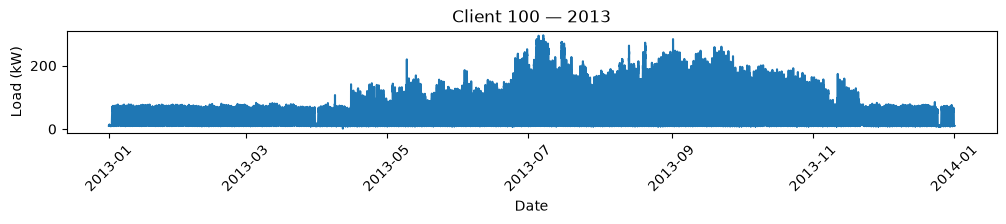

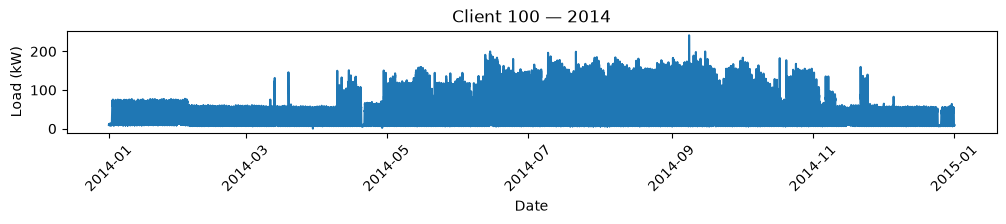

In [29]:
plot_ts_by_year_client(100)

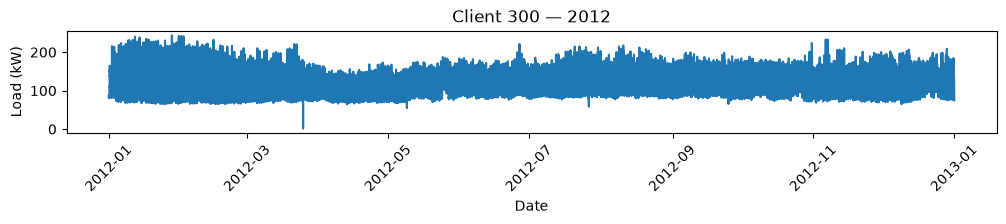

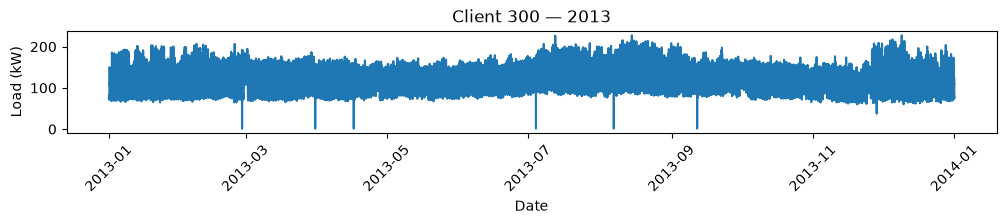

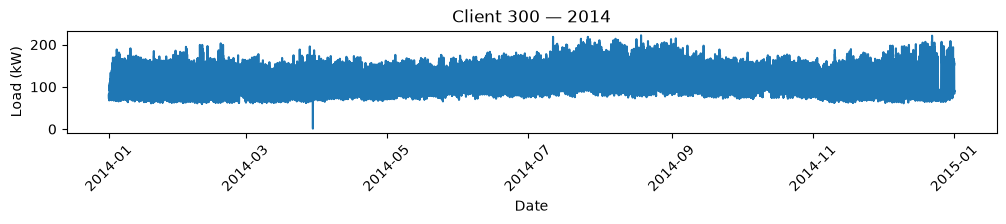

In [30]:
plot_ts_by_year_client(300)